In [15]:
import torch
import torch.nn as nn #导入神经网络模块
import torch.optim as optim #导入优化器模块,用于参数更新
from torchvision import datasets,transforms #从torchvision导入常用数据集mnist和数据预处理工具
from torch.utils.data import DataLoader #导入数据加载器,用于批量加载数据
#设备配置
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:{device}")
#数据预处理
transform=transforms.Compose([
    transforms.ToTensor(),#将PIL图像或NumPY数组转换为PyTorch张量,并将像素值从[0,255]缩放到[0,1]将原数据/255
    transforms.Normalize((0.1307,),(0.3081,))
#用均值和标准差标准化图像。MNIST的全局均值为0.1307,标准差为0.3081。公式(x-mean)/std,使数据分布接近标准正态
])
#加载数据集==下载/加载minist数据集
train_dataset=datasets.MNIST('./data',train=True,download=True,transform=transform)
test_dataset=datasets.MNIST('./data',train=False,download=True,transform=transform)
#创建数据加载器
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=1000,shuffle=False)#每批100-张图像,shuffle为True打乱训练数据顺序

class MLP(nn.Module): #继承nn.Module,定义自己的网络
    def __init__(self,use_dropout=False,dropout_rate=0.5):
        super(MLP,self).__init__()
        self.fc1=nn.Linear(28*28,128)
        self.fc2=nn.Linear(128,10)
        self.relu=nn.ReLU() #ReLU激活函数
        self.dropout=nn.Dropout(dropout_rate) if use_dropout else None #根据参数决定是否创建Dropout层
    def forward(self,x):
        x=x.view(-1,28*28)
        x=self.relu(self.fc1(x))#通过第一层全连接接ReLU激活
        if self.dropout is not None:
            x=self.dropout(x)
        x=self.fc2(x)#第二层全连接得到logits(未经softmax的分数)
        return x
#定义训练函数
def train(model,train_loader,optimizer,criterion,epochs=5):
    model.train() #将模型设置为训练模型
    for epoch in range(epochs):
        running_loss=0.0
        for images,labels in train_loader:
            images,labels=images.to(device),labels.to(device) #将数据移动到指定设备
            optimizer.zero_grad()
            outputs=model(images) #前向传播,得到预测logits
            loss=criterion(outputs,labels) #计算交叉熵损失
            loss.backward() #计算梯度
            optimizer.step() #根据梯度更新模型参数
            running_loss+=loss.item() #累加损失
        print(f"Epoch{epoch+1},Loss:{running_loss/len(train_loader):.4f}")
#定义测试函数
def test(model,test_loader):
    model.eval() #将模型设置为评估模式(禁用Dropout,BatchNorm使用全局统计)
    correct=0;total=0
    with torch.no_grad():#禁用梯度运算
        for images,labels in test_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            _,predicted=torch.max(outputs,1) #找出每行最大值的索引
            total+=labels.size(0) #累加batch大小
            correct+=(predicted==labels).sum().item() #统计正确预测数
        accuracy=100*correct/total #计算准确率百分比
        print(f"Test Accuracy:{accuracy:.2f}%")
        return accuracy
epochs=5
lr=0.001
criterion=nn.CrossEntropyLoss()
print("#不加Dropout")
model_no_drop=MLP(use_dropout=False).to(device)
optimizer=optim.Adam(model_no_drop.parameters(),lr=lr)
train(model_no_drop,train_loader,optimizer,criterion,epochs)
acc_no_drop=test(model_no_drop,test_loader)
print("#加Dropout")
model_with_drop=MLP(use_dropout=True,dropout_rate=0.5).to(device)
optimizer=optim.Adam(model_with_drop.parameters(),lr=lr)
train(model_with_drop,train_loader,optimizer,criterion,epochs)
acc_with_drop=test(model_with_drop,test_loader)
print(f"\n对比结果:不加Dropout准确率{acc_no_drop:.2f}%,加Dropout准确率{acc_with_drop:.2f}")

Using device:cpu
#不加Dropout
Epoch1,Loss:0.2644
Epoch2,Loss:0.1160
Epoch3,Loss:0.0809
Epoch4,Loss:0.0615
Epoch5,Loss:0.0489
Test Accuracy:97.67%
#加Dropout
Epoch1,Loss:0.3832
Epoch2,Loss:0.2260
Epoch3,Loss:0.1943
Epoch4,Loss:0.1737
Epoch5,Loss:0.1632
Test Accuracy:97.07%

对比结果:不加Dropout准确率97.67%,加Dropout准确率97.07


torch.Size([1, 28, 28])


array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

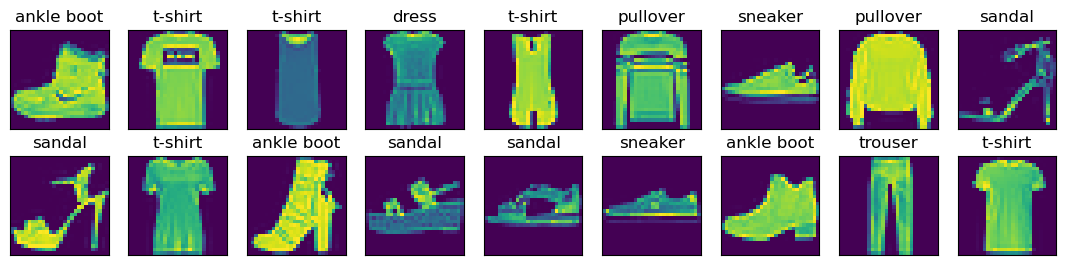

In [1]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn #导入神经网络模块
import torch.optim as optim #导入优化器模块,用于参数更新
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torch.utils import data
trans=transforms.ToTensor()
mnist_train=datasets.FashionMNIST(root="../data",train=True,transform=trans,download=True)
mnist_test=datasets.FashionMNIST(root="../data",train=False,transform=trans,download=True)
#每个类别由训练数据集中的6000张图像和测试数据集中1000张图像组成。Fashion-MNIST由10个类别图像组成
print(mnist_train[0][0].shape) #torch.Size([1, 28, 28]),数据集由灰度图像组成,其通道数为1,高度28、宽度28
def get_fashion_mnist_labels(labels): #@save
    #返回fashion-MNIST数据集的文本标签
    text_labels=['t-shirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bag','ankle boot']
    return [text_labels[int(i)] for i in labels]   
def show_images(imgs,num_rows,num_cols,titles=None,scale=1.5):#绘制图像列表
    figsize=(num_cols*scale,num_rows*scale)
    _,axes=plt.subplots(num_rows,num_cols,figsize=figsize)
    axes=axes.flatten()
    for i,(ax,img) in enumerate(zip(axes,imgs)):
        if torch.is_tensor(img):#图像张量
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)#PTL张量
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes
X,y=next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_images(X.reshape(18,28,28),2,9,titles=get_fashion_mnist_labels(y))

In [12]:
import torch
import torch.nn as nn
#定义验证函数
def calc_conv_output(input_size,kernel_size,padding=0,stride=1):
    #创建随机输入张量(batch,channels,height,width) batch-一批样本,channels通道数
    x=torch.randn(1,1,input_size,input_size)#卷积要求四维batch
    conv=nn.Conv2d(in_channels=1,out_channels=1,kernel_size=kernel_size,
    padding=padding,stride=stride)  #定义卷积层
    y=conv(x)
    #print(f"卷积核权重:{conv.weight};\n卷积偏置:{conv.bias}") conv生成卷积核
    #输出尺寸
    output_size=y.shape[2] #高度宽度,相同
    print("-"*60)
    print(f"输入{input_size}×{input_size},核{kernel_size}×{kernel_size},"
         f"padding={padding},stride={stride}->输出{output_size}*{output_size}")
    print("PyTorch 卷积输出尺寸验证")
calc_conv_output(32,5,0,1)
calc_conv_output(32,3,1,1)
calc_conv_output(32,5,2,1)
calc_conv_output(32,3,1,2)
calc_conv_output(28,5,2,1)

------------------------------------------------------------
输入32×32,核5×5,padding=0,stride=1->输出28*28
PyTorch 卷积输出尺寸验证
------------------------------------------------------------
输入32×32,核3×3,padding=1,stride=1->输出32*32
PyTorch 卷积输出尺寸验证
------------------------------------------------------------
输入32×32,核5×5,padding=2,stride=1->输出32*32
PyTorch 卷积输出尺寸验证
------------------------------------------------------------
输入32×32,核3×3,padding=1,stride=2->输出16*16
PyTorch 卷积输出尺寸验证
------------------------------------------------------------
输入28×28,核5×5,padding=2,stride=1->输出28*28
PyTorch 卷积输出尺寸验证


使用设备: cpu
训练集大小:60000
测试集大小:10000
开始训练...
Epoch  1/10 | Train Loss: 0.2613 | Train Acc: 92.11% | Test Loss: 0.0818 | Test Acc: 97.44%
Epoch  2/10 | Train Loss: 0.0763 | Train Acc: 97.64% | Test Loss: 0.0493 | Test Acc: 98.41%
Epoch  3/10 | Train Loss: 0.0533 | Train Acc: 98.36% | Test Loss: 0.0444 | Test Acc: 98.53%
Epoch  4/10 | Train Loss: 0.0418 | Train Acc: 98.67% | Test Loss: 0.0296 | Test Acc: 99.05%
提前停止！测试准确率已达到 99.05%
最终测试准确率: 99.05%
✅ 达到目标 (>98%)


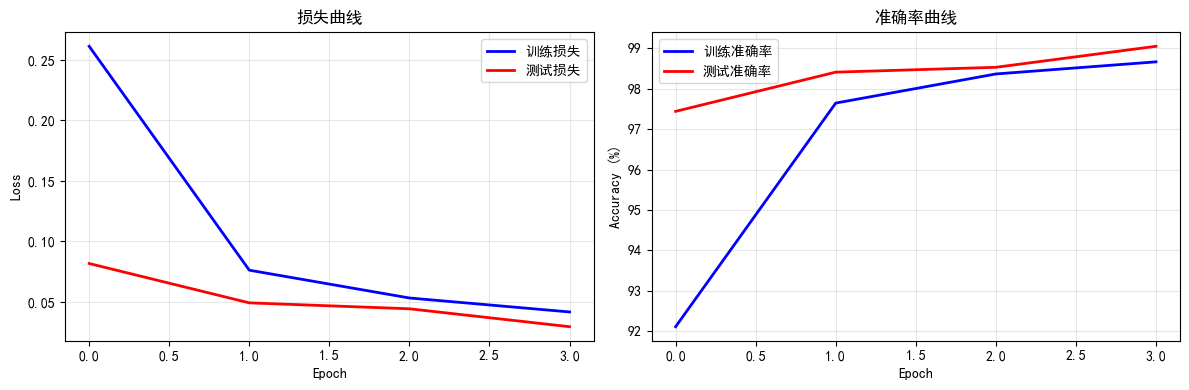

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
#数据预处理
#mnist原始尺寸28*28->leNet 32*32
transform=transforms.Compose([
   transforms.Resize(32),transforms.ToTensor(),transforms.Normalize((0.1307,),(0.3081,)) 
])
#下载并加载Mnist数据集
train_dataset=datasets.MNIST(root='./data',train=True,download=False,transform=transform)#之前下载过
test_dataset=datasets.MNIST(root='./data',train=False,download=False,transform=transform)
#数据加载器
batch_size=64 #batch批次
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
print(f"训练集大小:{len(train_dataset)}")
print(f"测试集大小:{len(test_dataset)}")
#定义LeNet模型
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet,self).__init__()
        #第一层C1(6,28,28)--5,1,0。变为6是因为out_channel=6,表示使用6个不同卷积核,每个核生成一个特征图--> 第二层S2(6,14,14)--2,2-->
        #第三层C3(16,10,10)--5,1,0,6,16(16个不同卷积核,每个核深度为6)-->第四层S4(16,5,5)--2,2-->第五层C5(120,1,1)--5,1,0,16,120。-->
        #展开+平连接层:(batch,120,1,1)->(batch,120) 全连接层 fc1:120->84 fc2:84->10。
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.pool2=nn.AvgPool2d(2)
        self.conv3=nn.Conv2d(16,120,5)
        #全连接层1:120->84
        self.fc1=nn.Linear(120,84)
        self.fc2=nn.Linear(84,10)
        self.relu=nn.ReLU()
    def forward(self,x):
        #前向传播 x:输入张量,形状(batch,1,32,32)
        #第一卷积块: Conv1 → ReLU → Pool1
        x = self.relu(self.conv1(x))   # (batch, 6, 28, 28)
        x = self.pool1(x)              # (batch, 6, 14, 14)
        #第二卷积块: Conv2 → ReLU → Pool2
        x = self.relu(self.conv2(x))   # (batch, 16, 10, 10)
        x = self.pool2(x)              # (batch, 16, 5, 5)
        #第三卷积块: Conv3 → ReLU
        x = self.relu(self.conv3(x))   # (batch, 120, 1, 1)
        # 展平: 将 (batch, 120, 1, 1) → (batch, 120)
        x = x.view(x.size(0), -1)      # 或 x = x.flatten(1)
        # 全连接层
        x = self.relu(self.fc1(x))     # (batch, 84)
        x = self.fc2(x)                 # (batch, 10)
        return x
#训练函数
def train(model,train_loader,optimizer,criterion,device):
    #训练一个epoch
    model.train();running_loss=0.0;correct=0;total=0
    for batch_idx,(data,target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        # 前向传播
        optimizer.zero_grad() #清零梯度
        output = model(data)  #模型预测
        loss = criterion(output, target) #计算损失 
        # 反向传播
        loss.backward()                # 计算梯度
        optimizer.step()               # 更新参数
        # 统计
        running_loss += loss.item() #累加当前损失之
        _,predicted = torch.max(output, 1)#predicted 得到预测的类别索引（0-9）。获取模型预测结果
        total+=target.size(0) #累加总样本数 target.size(0)是当前批次的样本数量
        correct+=(predicted == target).sum().item()#累加正确预测数：比较预测值和真实值，求和得到正确个数，.item()转为Python数字
    epoch_loss=running_loss / len(train_loader) #循环结束后，计算整个epoch的平均损失（
    epoch_acc=100.0 * correct / total #计算整个epoch的准确率百分比（正确数 / 总数 × 100）
    return epoch_loss, epoch_acc #返回当前epoch的平均损失和准确率
    #神经网络就像一个公式：输出 = 权重 × 输入 + 偏置。权重和偏置：就是网络要学习的参数（比如LeNet-5里几万个参数）。损失loss：衡量预测对不对（越小越好）
    #卷积核参数不断训练,全连接学怎么分类。
def test(model, test_loader, criterion, device):
    #测试模型性能
    model.eval()  # 设置为评估模式
    test_loss = 0.0;correct = 0;total = 0
    with torch.no_grad():  # 不计算梯度，节省内存
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    avg_loss = test_loss / len(test_loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy #测试不需要更新参数
#6. 训练主程序
# 初始化模型、损失函数、优化器
model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()  # 交叉熵损失（适用于多分类）
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练参数
num_epochs = 10
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print("开始训练...")
print("=" * 60)

for epoch in range(1, num_epochs + 1):
    # 训练
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 测试
    test_loss, test_acc = test(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    
    # 提前停止：如果准确率超过 99%
    if test_acc >= 99.0:
        print(f"提前停止！测试准确率已达到 {test_acc:.2f}%")
        break
#7. 最终结果
print("=" * 60)
print(f"最终测试准确率: {test_accs[-1]:.2f}%")
if test_accs[-1] >= 98:
    print("✅ 达到目标 (>98%)")
else:
    print("❌ 未达到目标，可尝试增加 epoch 或调整学习率")

#8. 可视化
plt.figure(figsize=(12, 4))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='训练损失', linewidth=2)
plt.plot(test_losses, 'r-', label='测试损失', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('损失曲线')
plt.legend()
plt.grid(True, alpha=0.3)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(train_accs, 'b-', label='训练准确率', linewidth=2)
plt.plot(test_accs, 'r-', label='测试准确率', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('准确率曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

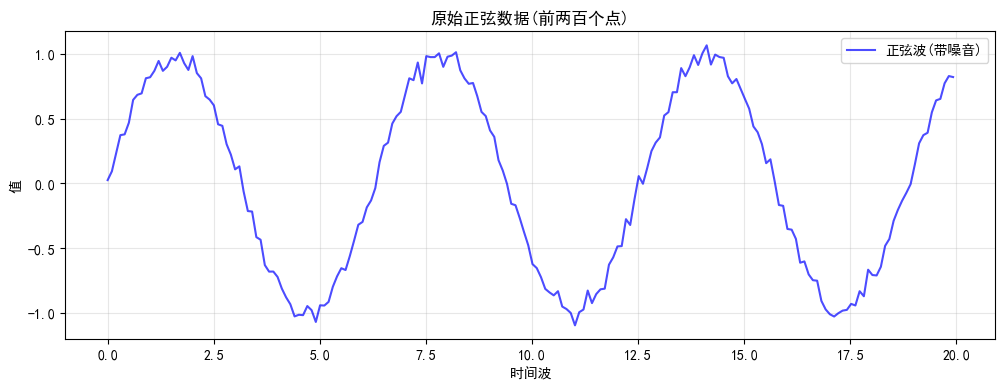

Epoch 20/200, Loss: 0.060707
Epoch 40/200, Loss: 0.020660
Epoch 60/200, Loss: 0.023633
Epoch 80/200, Loss: 0.007451
Epoch 100/200, Loss: 0.005327
Epoch 120/200, Loss: 0.005154
Epoch 140/200, Loss: 0.005076
Epoch 160/200, Loss: 0.005030
Epoch 180/200, Loss: 0.004993
Epoch 200/200, Loss: 0.004964

训练集 RMSE: 0.070448
测试集 RMSE: 0.068910


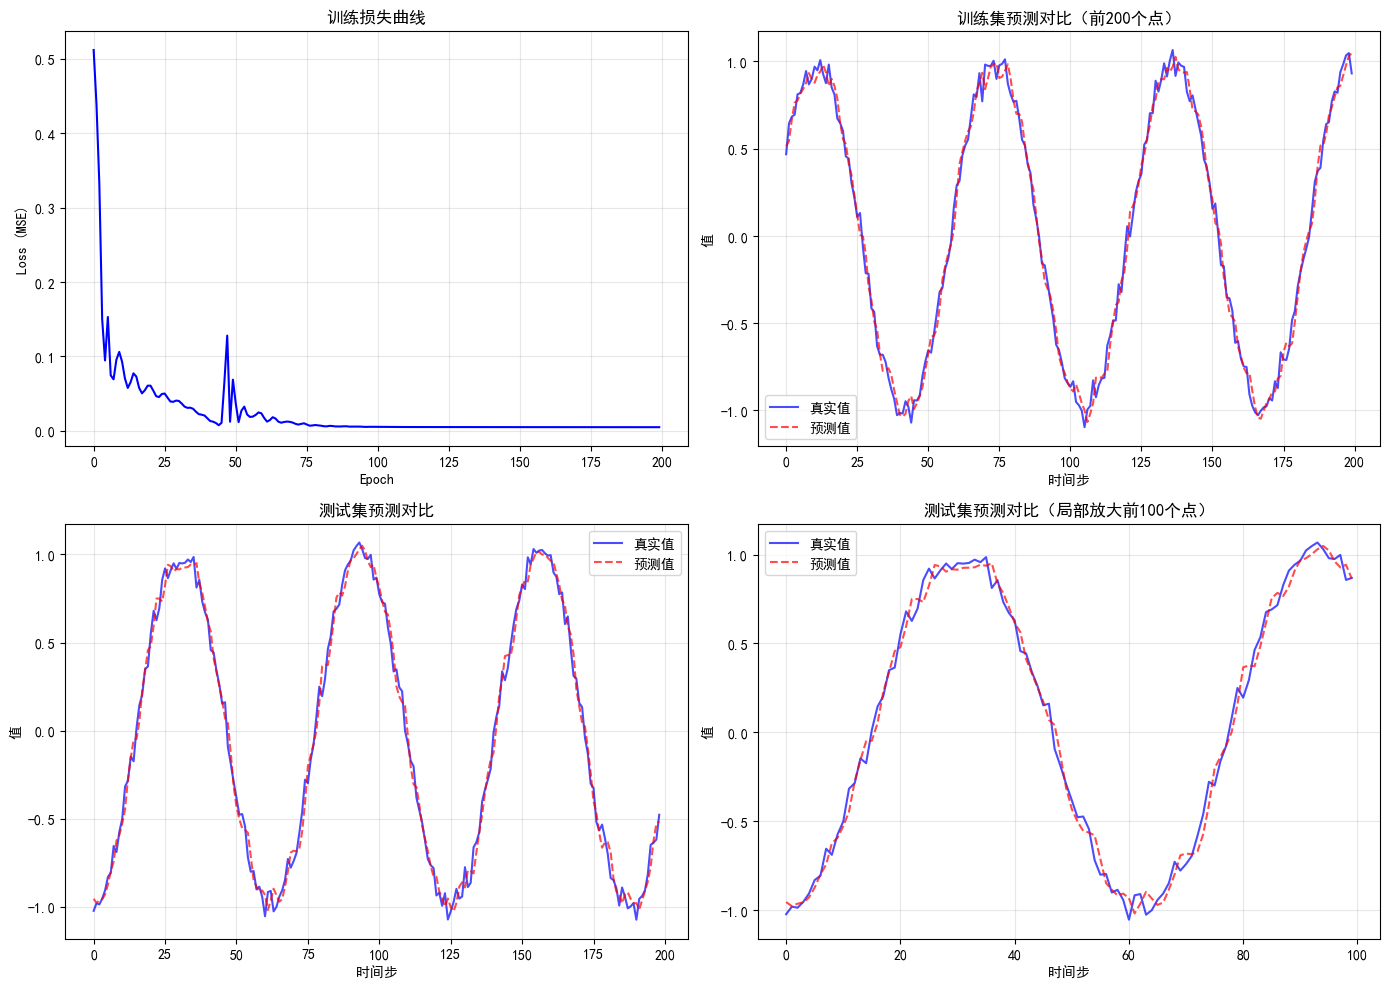

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#1.生成正弦波数据
np.random.seed(42);torch.manual_seed(42)
seq_length=1000
x=np.linspace(0,100,seq_length)#0-100之间有1000个点
y=np.sin(x)+np.random.normal(0,0.05,seq_length) #正弦波噪音,normal高斯噪音.均值0,标准差0.05
plt.figure(figsize=(12,4))
plt.plot(x[:200],y[:200],'b',alpha=0.7,label='正弦波(带噪音)')
plt.xlabel('时间波');plt.ylabel('值');plt.title('原始正弦数据(前两百个点)')
plt.legend();plt.grid(True,alpha=0.3);plt.show()

#2.构建训练数据
def create_sequences(data,seq_len=5):
    X,y=[],[]
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len]) #取连续seq_len个点作为输入(这里前5个)
        y.append(data[i+seq_len]) #下一个点作为输出(标签) 下一个点当输出
    return np.array(X),np.array(y)
#将一维时间序列转换为监督学习所需的(输入序列,目标值)对。模型从过去几个点预测下一个点的映射关系。
#例如:data=[a,b,c,d,e,f],seq_len=2,则: 输入[a,b]->目标c。输入[b,c]->目标d,输入[c,d]->目标e
seq_len=5
X_data, y_data = create_sequences(y, seq_len)#X_data形状(995,5)共995个样本,每个样本有连续5个点。
X_tensor=torch.FloatTensor(X_data).unsqueeze(-1) #(995,5)-->(995,5,1)
y_tensor = torch.FloatTensor(y_data).unsqueeze(-1)  # (995,) → (995,1)
#unsqueeze(-1)在最后添加一维。LSTM的层输入要求形状为(batch,sequence_length,input_features)
#将数据分成两部分:训练集(前80%),测试集(20%)。
train_size = int(len(X_tensor) * 0.8) #X_tensor 995个
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]#0~795,796~999 训练集796 测试集199个
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

# 3.定义 LSTM 模型
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
    #input_size:每个时间点的特征数(就是正弦值),hidden_size:LSTM内部隐藏状态的维度,记忆单元的数量。值越大模型容量越大,计算量也越大。
    #堆叠两层LSTM,第二层以第一层的输出为输入,可以学习更高层次的抽象。
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        #h0,c0分别是初始印隐藏状态和初始细胞状态。
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))#out包含所有时间步的输出,形状
        out = out[:, -1, :]
        out = self.fc(out)#最后经过全连接层self.fc将hidden_size维度映射到1,得到预测值
        return out

#4. 训练模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMPredictor(input_size=1, hidden_size=64, num_layers=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)#优化器负责调整参数让损失变小。
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
num_epochs = 200
train_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

#5. 测试模型
model.eval()
with torch.no_grad():
    train_pred = model(X_train).cpu().numpy()
    test_pred = model(X_test).cpu().numpy()

train_pred = train_pred.flatten()
test_pred = test_pred.flatten()
y_train_np = y_train.cpu().numpy().flatten()
y_test_np = y_test.cpu().numpy().flatten()

from sklearn.metrics import mean_squared_error
train_rmse = np.sqrt(mean_squared_error(y_train_np, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_np, test_pred))
print(f"\n训练集 RMSE: {train_rmse:.6f}")
print(f"测试集 RMSE: {test_rmse:.6f}")

# 6。可视化预测结果
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(train_losses, 'b-', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('训练损失曲线')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(y_train_np[:200], 'b-', label='真实值', alpha=0.7)
plt.plot(train_pred[:200], 'r--', label='预测值', alpha=0.7)
plt.xlabel('时间步')
plt.ylabel('值')
plt.title('训练集预测对比（前200个点）')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(y_test_np, 'b-', label='真实值', alpha=0.7)
plt.plot(test_pred, 'r--', label='预测值', alpha=0.7)
plt.xlabel('时间步')
plt.ylabel('值')
plt.title('测试集预测对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(y_test_np[:100], 'b-', label='真实值', alpha=0.7)
plt.plot(test_pred[:100], 'r--', label='预测值', alpha=0.7)
plt.xlabel('时间步')
plt.ylabel('值')
plt.title('测试集预测对比（局部放大前100个点）')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()